# 🎨 Spectral Manifold Learning (Laplacian Eigenmaps)

В этом эксперименте реализуем классический пример *спектрального обучения на многообразиях*.
Мы возьмём трёхмерное многообразие — "Swiss Roll" — и покажем, как метод **Laplacian Eigenmaps**
раскручивает его в двумерное пространство, сохраняя геометрию данных.


In [3]:
!pip install pydiffmap

In [68]:
# === Импорты ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import (
    SpectralEmbedding, Isomap, LocallyLinearEmbedding, MDS
)
from pydiffmap import diffusion_map as dm
from scipy import sparse
from scipy.sparse.linalg import eigsh
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import MDS
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.neighbors import kneighbors_graph


from scipy.sparse import csr_matrix, diags, eye
from scipy.sparse.linalg import eigsh



/tmp/ipython-input-4077273182.py:15: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


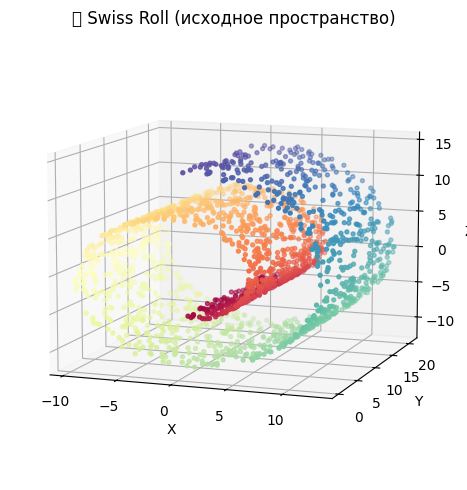

In [69]:
# === Данные ===
X, color = make_swiss_roll(n_samples=2000, noise=0.05, random_state=42)

# === 🌈 Визуализация исходного Swiss Roll ===
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (нужно для 3D)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap='Spectral', s=8)
ax.set_title("🌈 Swiss Roll (исходное пространство)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.view_init(elev=10, azim=-70)
plt.tight_layout()
plt.show()


/tmp/ipython-input-4048785979.py:126: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


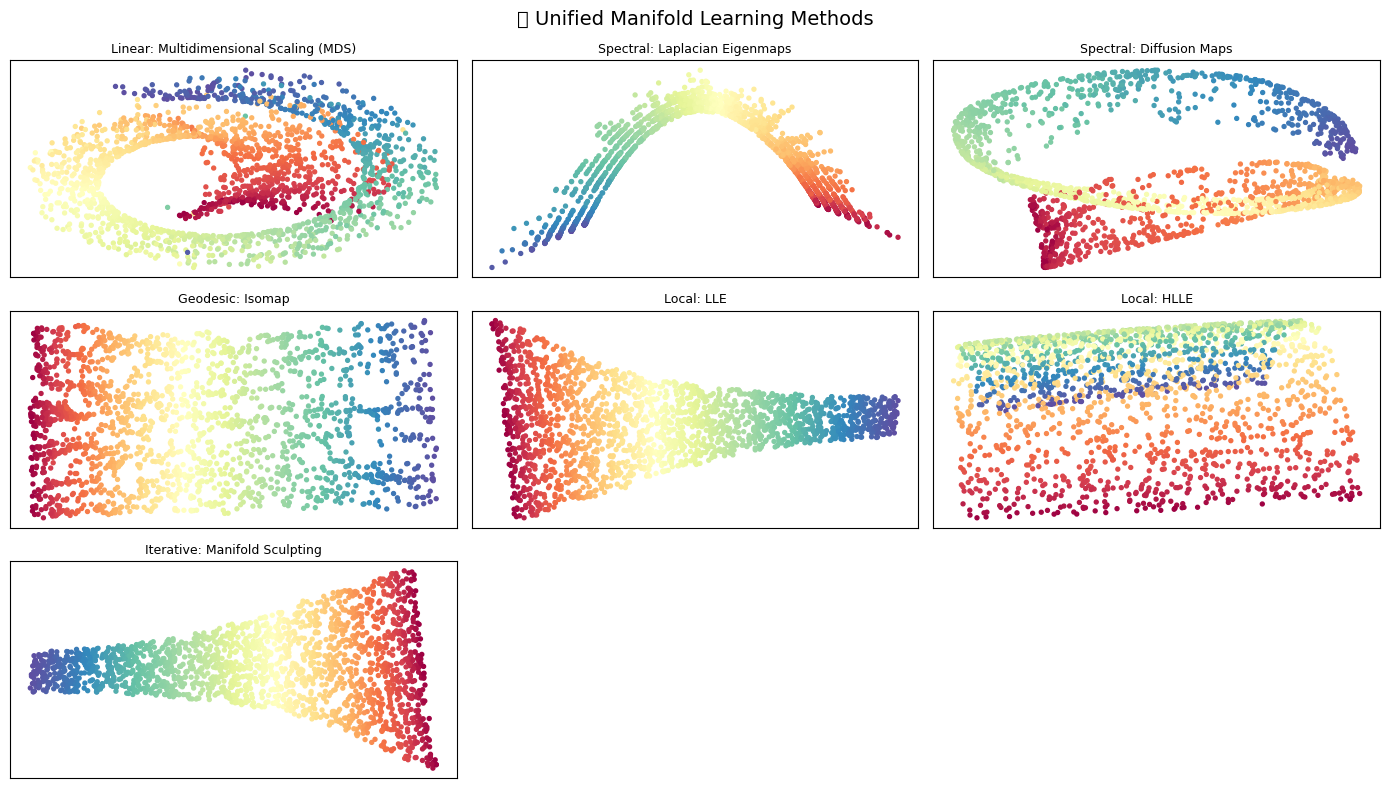

In [98]:
# === 0️⃣ Multidimensional Scaling (MDS) ===
def mds(X, n_components=2):
    """Классический MDS: сохраняет евклидовы расстояния"""
    return MDS(
        n_components=n_components, n_init=4, max_iter=60,
        random_state=42, dissimilarity='euclidean'
    ).fit_transform(X)

def laplacian_eigenmaps(X, n_neighbors=10, n_components=2, t=30):
    """
    Нормализованный Laplacian Eigenmaps (вариант L = I - D^{-1} W)
    ---
    Соответствует интегральной нормировке ядра при равномерном семплировании.
    """
    # === 1️⃣ Строим граф соседей ===
    G = kneighbors_graph(X, n_neighbors, mode='distance', include_self=False)
    G = 0.5 * (G + G.T)  # симметризация

    # === 2️⃣ Параметр ядра t ===
    if t is None:
        t = np.median(G.data) ** 2
        print(f"[info] Автоматически выбран t = {t:.4e}")

    # === 3️⃣ Ядро Гаусса ===
    W = G.copy()
    W.data = np.exp(-(W.data ** 2) / t)

    # === 4️⃣ Матрица степеней и нормализованный лапласиан ===
    D = np.array(W.sum(axis=1)).flatten()
    D_inv = diags(1.0 / D)
    L = eye(W.shape[0]) - D_inv @ W  # I - D^{-1}W

    # === 5️⃣ Собственные значения и векторы ===
    vals, vecs = eigsh(L, k=n_components + 1, sigma=0.0, which='LM')

    # === 6️⃣ Пропускаем тривиальное собственное значение (λ₀≈0) ===
    embedding = vecs[:, 1:n_components + 1]
    return embedding
# === 2️⃣ Diffusion Maps ===
def diffusion_maps_advanced(
    X,
    n_evecs=5,
    alpha=0.05,
    epsilon=10,
    k=70,
    kernel_type='gaussian',
    n_jobs=-1
):
    """
    Устойчивый вариант Diffusion Maps для sklearn >=1.4
    """
    mydmap = dm.DiffusionMap.from_sklearn(
        n_evecs=n_evecs,
        alpha=alpha,
        epsilon=epsilon,
        k=k,  # ✅ передаём прямо сюда
        kernel_type=kernel_type,
        neighbor_params={'n_jobs': n_jobs}  # ⚙️ только прочие параметры
    )

    embedding = mydmap.fit_transform(X)
    # eigvals = mydmap.eigenvalues_

    # Отбрасываем первую (тривиальную) компоненту
    return embedding[:, 1:3]

# === 3️⃣ Isomap ===
def isomap(X, n_neighbors=10):
    return Isomap(n_neighbors=n_neighbors, n_components=2).fit_transform(X)

# === 4️⃣ Locally Linear Embedding (LLE) ===
def lle(X, n_neighbors=12):
    return LocallyLinearEmbedding(
        n_neighbors=n_neighbors, n_components=2, method='standard'
    ).fit_transform(X)

# === 5️⃣ Hessian LLE (HLLE) ===
def hlle(X, n_neighbors=30):
    return LocallyLinearEmbedding(
        n_neighbors=n_neighbors, n_components=2, method='hessian'
    ).fit_transform(X)

# === 6️⃣ Manifold Sculpting (приближённая реализация) ===
def manifold_sculpting(X, n_neighbors=12, n_iter=5):
    base = LocallyLinearEmbedding(
        n_neighbors=n_neighbors, n_components=2, method='standard'
    )
    Y = base.fit_transform(X)
    for _ in range(n_iter):
        mean_dist = np.mean(np.linalg.norm(Y[:, None, :] - Y[None, :, :], axis=2))
        scale = 1.0 / mean_dist
        Y *= scale * 1.05
        Y -= Y.mean(axis=0)
    return Y

# === 🌀 Сравнение визуализаций ===
methods = {
    "Linear: Multidimensional Scaling (MDS)": mds,
    "Spectral: Laplacian Eigenmaps": laplacian_eigenmaps,
    "Spectral: Diffusion Maps": diffusion_maps_advanced,
    "Geodesic: Isomap": isomap,
    "Local: LLE": lle,
    "Local: HLLE": hlle,
    "Iterative: Manifold Sculpting": manifold_sculpting,
}

rows = int(np.ceil(len(methods) / 3))
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(14, 8))
axes = axes.ravel()

for ax, (title, func) in zip(axes, methods.items()):
    # try:
    Y = func(X)
    ax.scatter(Y[:, 0], Y[:, 1], c=color, cmap='Spectral', s=8)
    ax.set_title(title, fontsize=9)
    # except Exception as e:
    #     ax.text(0.5, 0.5, f"Error: {e}", ha='center', va='center', fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
    ax.grid(alpha=0.2)

for ax in axes[len(methods):]:
    ax.axis("off")

plt.suptitle("🌀 Unified Manifold Learning Methods", fontsize=14)
plt.tight_layout()
plt.show()


# THE END


# SOME FUN

## DIffusion map in Stochastic Gradient Descent

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pydiffmap import diffusion_map as dm
from pydiffmap import diffusion_map as dm
from scipy.sparse.linalg import ArpackNoConvergence

def stable_diffusion_embedding(traj, n_evecs=5, alpha=0.5, epsilon='bgh'):
    """
    Устойчивое построение Diffusion Maps, совместимое с разными версиями pydiffmap.
    """
    try:
        # Новый безопасный способ (через from_sklearn)
        mydmap = dm.DiffusionMap.from_sklearn(n_evecs=n_evecs, alpha=alpha, epsilon=epsilon)
        embedding = mydmap.fit_transform(traj)
    except ArpackNoConvergence:
        print("⚠️ ARPACK не сошёлся — уменьшаем число собственных векторов.")
        mydmap = dm.DiffusionMap.from_sklearn(n_evecs=min(3, n_evecs), alpha=alpha, epsilon=epsilon)
        embedding = mydmap.fit_transform(traj)
    except Exception as e:
        print(f"⚠️ DiffusionMap не сошёлся: {e}\n→ Переходим в fallback на PCA.")
        from sklearn.decomposition import PCA
        embedding = PCA(n_components=min(3, n_evecs)).fit_transform(traj)
    return embedding



# === 0️⃣ Универсальный движок ===
def visualize_loss_and_sgd(
    loss_fn, grad_fn,
    xlim=(-4, 4), ylim=(-4, 4),
    n_grid=400,
    n_steps=500, eta=0.03, noise_std=0.07,
    start=(2.5, 2.5), n_evecs=5,
    levels=100, title="🌋 Ландшафт и динамика SGD"
):
    """
    Универсальная функция:
    1. Визуализирует ландшафт 𝓛(x,y)
    2. Симулирует стохастический SGD
    3. Строит Diffusion Maps embedding
    """
    # === 1️⃣ Ландшафт ===
    xs = np.linspace(*xlim, n_grid)
    ys = np.linspace(*ylim, n_grid)
    Xg, Yg = np.meshgrid(xs, ys)
    Z = np.zeros_like(Xg)
    for i in range(n_grid):
        for j in range(n_grid):
            Z[i, j] = loss_fn((Xg[i, j], Yg[i, j]))

    plt.figure(figsize=(7,6))
    plt.contourf(Xg, Yg, Z, levels=levels, cmap='Spectral_r')
    plt.colorbar(label="Loss value")
    plt.title(title)
    plt.xlabel("x"); plt.ylabel("y")
    plt.axis('equal')
    plt.show()

    # === 2️⃣ Симуляция SGD ===
    def simulate_sgd():
        traj = np.zeros((n_steps, 2))
        theta = np.array(start, dtype=float)
        for t in range(n_steps):
            g = grad_fn(theta)
            noise = np.random.randn(2) * noise_std
            theta = theta - eta * g + noise
            traj[t] = theta
        return traj

    np.random.seed(0)
    traj = simulate_sgd()

    # === 3️⃣ Визуализация траектории ===
    plt.figure(figsize=(7,6))
    plt.contourf(Xg, Yg, Z, levels=levels, cmap='Spectral_r', alpha=0.85)
    plt.plot(traj[:,0], traj[:,1], lw=0.5, color='black', alpha=0.6)
    plt.scatter(traj[::20,0], traj[::20,1], c=np.arange(0,len(traj[::20])), cmap='plasma', s=6)
    plt.title("💨 Траектория SGD")
    plt.xlabel("x"); plt.ylabel("y")
    plt.axis('equal'); plt.grid(alpha=0.3)
    plt.show()

    # === 4️⃣ Diffusion Maps ===
    mydmap = dm.DiffusionMap.from_sklearn(n_evecs=n_evecs, alpha=0.5, epsilon='bgh')
    embedding = stable_diffusion_embedding(traj)


    # === 5️⃣ Визуализация спектральных координат ===
    fig, axs = plt.subplots(1, 2, figsize=(12,5))

    axs[0].scatter(traj[:,0], traj[:,1], c=np.arange(len(traj)), cmap='plasma', s=5)
    axs[0].set_title("💨 Траектория SGD (x,y)")
    axs[0].set_xlabel("x"); axs[0].set_ylabel("y"); axs[0].axis('equal')

    axs[1].scatter(embedding[:,1], embedding[:,2], c=np.arange(len(traj)), cmap='plasma', s=5)
    axs[1].set_title("🌈 Diffusion Map — медленные координаты SGD")
    axs[1].set_xlabel("ψ₁"); axs[1].set_ylabel("ψ₂")

    plt.tight_layout()
    plt.show()


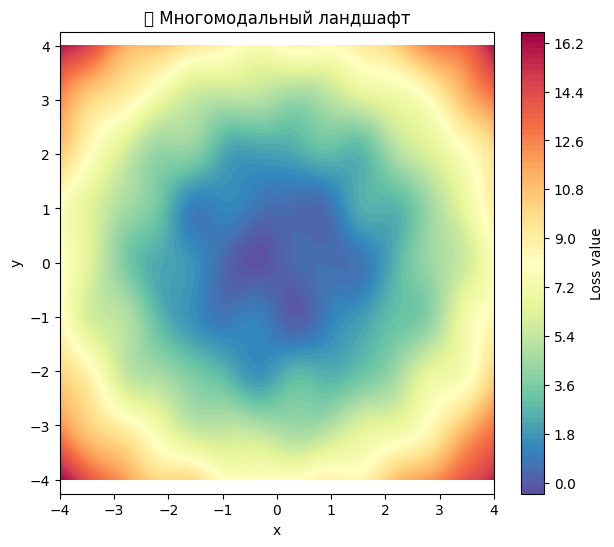

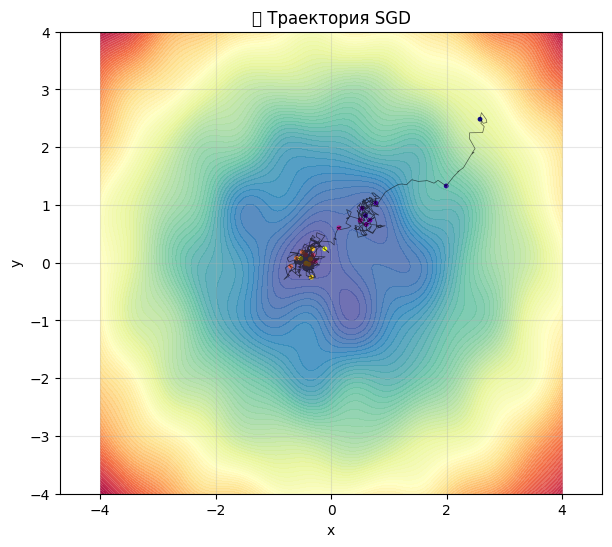

⚠️ ARPACK не сошёлся — уменьшаем число собственных векторов.


ArpackNoConvergence: ARPACK error -1: No convergence (5001 iterations, 0/4 eigenvectors converged) [ARPACK error -14: DNAUPD  did not find any eigenvalues to sufficient accuracy.]

In [ ]:
def loss(theta):
    x, y = theta
    return (
        0.5 * (x**2 + y**2)
        + 0.4 * np.sin(3*x) * np.cos(3*y)
        + 0.25 * np.sin(5*x) * np.sin(2*y)
    )

def grad(theta):
    x, y = theta
    dLdx = x + 1.2 * np.cos(3*x) * np.cos(3*y) + 1.25 * np.cos(5*x) * np.sin(2*y)
    dLdy = y - 1.2 * np.sin(3*x) * np.sin(3*y) + 0.5 * np.sin(5*x) * np.cos(2*y)
    return np.array([dLdx, dLdy])

visualize_loss_and_sgd(loss, grad, n_steps = 500, title="🌋 Многомодальный ландшафт")


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


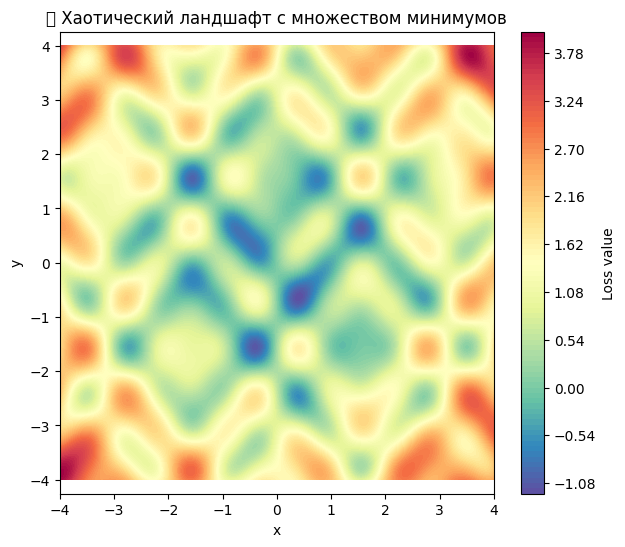

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128168 (\N{DASH SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


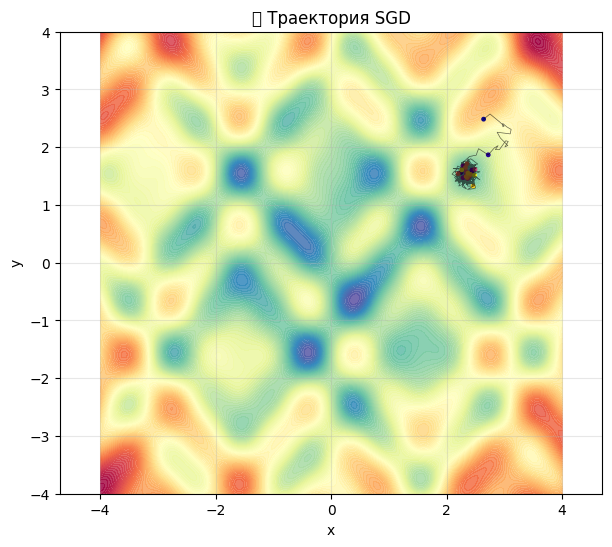

⚠️ ARPACK не сошёлся — уменьшаем число собственных векторов.


ArpackNoConvergence: ARPACK error -1: No convergence (5001 iterations, 0/4 eigenvectors converged) [ARPACK error -14: DNAUPD  did not find any eigenvalues to sufficient accuracy.]

In [ ]:
def loss(theta):
    x, y = theta
    return np.sin(3*x)*np.sin(3*y) + 0.5*np.sin(5*x)*np.cos(4*y) + 0.1*(x**2+y**2)

def grad(theta):
    x, y = theta
    dLdx = 3*np.cos(3*x)*np.sin(3*y) + 2.5*np.cos(5*x)*np.cos(4*y) + 0.2*x
    dLdy = 3*np.sin(3*x)*np.cos(3*y) - 2*np.sin(5*x)*np.sin(4*y) + 0.2*y
    return np.array([dLdx, dLdy])

visualize_loss_and_sgd(loss, grad, title="🔥 Хаотический ландшафт с множеством минимумов")


/tmp/ipython-input-1718352618.py:77: UserWarning: Glyph 128168 (\N{DASH SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128168 (\N{DASH SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


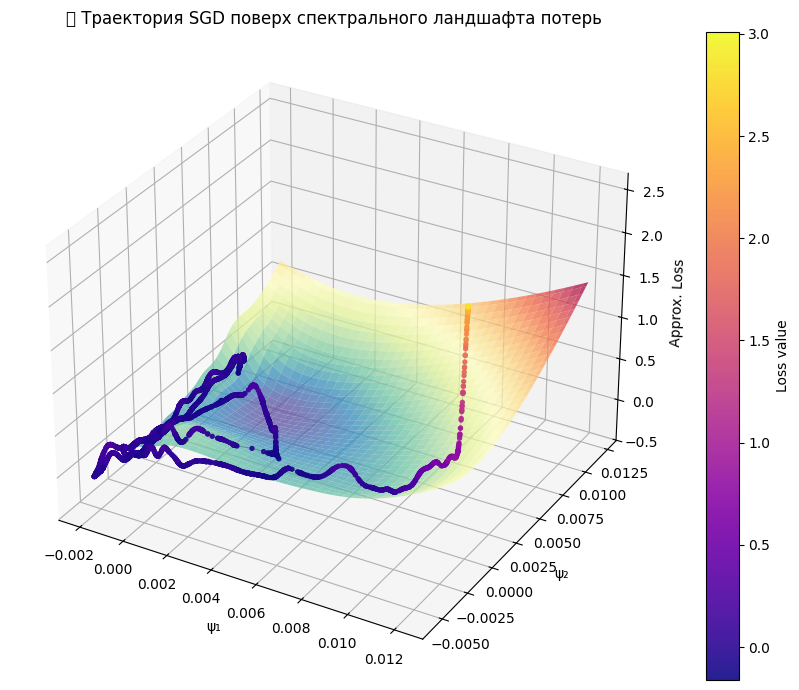

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import SpectralEmbedding
from scipy.interpolate import Rbf
from mpl_toolkits.mplot3d import Axes3D

# === 1️⃣ Функция потерь в R^10 ===
def loss(theta):
    x1, x2 = theta[0], theta[1]
    rest = theta[2:]
    return (
        0.5*(x1**2 + 0.2*x2**2)
        + 0.3*np.sin(3*x1)*np.cos(2*x2)
        + 0.1*np.sum(rest**2)
    )

def grad(theta):
    x1, x2 = theta[0], theta[1]
    rest = theta[2:]
    g = np.zeros_like(theta)
    g[0] = x1 + 0.9*np.cos(3*x1)*np.cos(2*x2)
    g[1] = 0.2*x2 - 0.6*np.sin(3*x1)*np.sin(2*x2)
    g[2:] = 0.2 * rest
    return g

# === 2️⃣ Симуляция стохастического SGD ===
def simulate_sgd(n_steps=5000, eta=0.03, noise_std=0.05):
    dim = 10
    traj = np.zeros((n_steps, dim))
    theta = np.random.randn(dim) * 2.0
    for t in range(n_steps):
        g = grad(theta)
        noise = np.random.randn(dim) * noise_std
        theta = theta - eta * g + noise
        traj[t] = theta
    return traj

np.random.seed(42)
traj = simulate_sgd()

# === 3️⃣ Спектральное подпространство (10D → 3D) ===
embedding = SpectralEmbedding(n_components=3, n_neighbors=20).fit_transform(traj)
loss_vals = np.array([loss(theta) for theta in traj])

# === 4️⃣ Аппроксимация функции лосса на manifold (RBF) ===
x, y, z = embedding[:,0], embedding[:,1], embedding[:,2]
rbf = Rbf(x, y, z, loss_vals, function='multiquadric', smooth=0.5)

# === 5️⃣ Генерация поверхности лосса в подпространстве (ψ₁–ψ₂, фиксируем ψ₃≈0) ===
grid_lin = np.linspace(x.min(), x.max(), 70)
Xg, Yg = np.meshgrid(grid_lin, grid_lin)
Zg = np.zeros_like(Xg)
for i in range(Xg.shape[0]):
    for j in range(Xg.shape[1]):
        Zg[i,j] = rbf(Xg[i,j], Yg[i,j], 0.0)

# === 6️⃣ Визуализация: поверхность + траектория ===
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# поверхность лосса
surf = ax.plot_surface(Xg, Yg, Zg, cmap='Spectral_r', alpha=0.75, linewidth=0, antialiased=True)

# траектория SGD поверх поверхности
traj_z = rbf(embedding[:,0], embedding[:,1], embedding[:,2])
p = ax.scatter(
    embedding[:,0], embedding[:,1], traj_z,
    c=loss_vals, cmap='plasma', s=8, alpha=0.9
)
ax.plot(embedding[:,0], embedding[:,1], traj_z, color='black', lw=0.6, alpha=0.7)

# оформление
fig.colorbar(p, ax=ax, label="Loss value")
ax.set_title("💨 Траектория SGD поверх спектрального ландшафта потерь")
ax.set_xlabel("ψ₁"); ax.set_ylabel("ψ₂"); ax.set_zlabel("Approx. Loss")
ax.view_init(30, -60)
plt.tight_layout()
plt.show()


/tmp/ipython-input-3168835724.py:81: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3168835724.py:81: UserWarning: Glyph 120027 (\N{MATHEMATICAL BOLD SCRIPT CAPITAL L}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3168835724.py:81: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 120027 (\N{MATHEMATICAL BOLD SCRIPT CAPITAL L}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  fig.canvas.print_fig

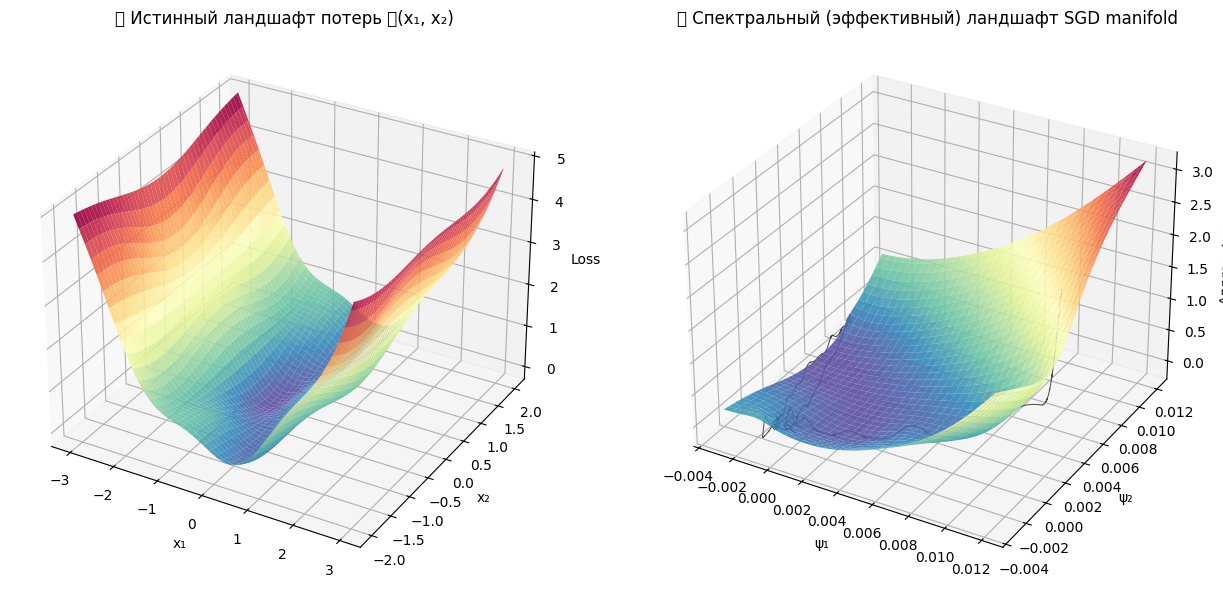

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import SpectralEmbedding
from scipy.interpolate import Rbf
from mpl_toolkits.mplot3d import Axes3D

# === 1️⃣ "Истинный" loss landscape в первых двух координатах ===
def true_loss(x1, x2):
    return 0.5*(x1**2 + 0.2*x2**2) + 0.3*np.sin(3*x1)*np.cos(2*x2)

# === 2️⃣ Полный 10D loss с шумовыми направлениями ===
def loss(theta):
    x1, x2 = theta[0], theta[1]
    rest = theta[2:]
    return true_loss(x1, x2) + 0.1*np.sum(rest**2)

def grad(theta):
    x1, x2 = theta[0], theta[1]
    rest = theta[2:]
    g = np.zeros_like(theta)
    g[0] = x1 + 0.9*np.cos(3*x1)*np.cos(2*x2)
    g[1] = 0.2*x2 - 0.6*np.sin(3*x1)*np.sin(2*x2)
    g[2:] = 0.2 * rest
    return g

# === 3️⃣ Симуляция стохастического GD в R^10 ===
def simulate_sgd(n_steps=4000, eta=0.03, noise_std=0.05):
    dim = 10
    traj = np.zeros((n_steps, dim))
    theta = np.random.randn(dim) * 2.0
    for t in range(n_steps):
        g = grad(theta)
        noise = np.random.randn(dim) * noise_std
        theta = theta - eta * g + noise
        traj[t] = theta
    return traj

np.random.seed(42)
traj = simulate_sgd()
loss_vals = np.array([loss(theta) for theta in traj])

# === 4️⃣ Спектральное подпространство (10D → 3D) ===
embedding = SpectralEmbedding(n_components=3, n_neighbors=25).fit_transform(traj)

# === 5️⃣ Аппроксимация "эффективного" лосса на manifold (RBF) ===
x, y, z = embedding[:,0], embedding[:,1], embedding[:,2]
rbf = Rbf(x, y, z, loss_vals, function='multiquadric', smooth=0.5)

grid_lin = np.linspace(x.min(), x.max(), 70)
Xg, Yg = np.meshgrid(grid_lin, grid_lin)
Zg_spec = np.zeros_like(Xg)
for i in range(Xg.shape[0]):
    for j in range(Xg.shape[1]):
        Zg_spec[i,j] = rbf(Xg[i,j], Yg[i,j], 0.0)

# === 6️⃣ Реальный loss landscape ===
x1s = np.linspace(-3, 3, 100)
x2s = np.linspace(-2, 2, 100)
X1, X2 = np.meshgrid(x1s, x2s)
Z_true = true_loss(X1, X2)

# === 7️⃣ Визуализация сравнения ===
fig = plt.figure(figsize=(13,6))

# (a) Реальный ландшафт
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X1, X2, Z_true, cmap='Spectral_r', alpha=0.9, linewidth=0)
ax1.set_title("🎯 Истинный ландшафт потерь 𝓛(x₁, x₂)")
ax1.set_xlabel("x₁"); ax1.set_ylabel("x₂"); ax1.set_zlabel("Loss")
ax1.view_init(30, -60)

# (b) Спектральный эффективный ландшафт
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(Xg, Yg, Zg_spec, cmap='Spectral_r', alpha=0.9, linewidth=0)
ax2.plot(embedding[:,0], embedding[:,1], rbf(embedding[:,0], embedding[:,1], embedding[:,2]),
         color='black', lw=0.7, alpha=0.7)
ax2.set_title("🌈 Спектральный (эффективный) ландшафт SGD manifold")
ax2.set_xlabel("ψ₁"); ax2.set_ylabel("ψ₂"); ax2.set_zlabel("Approx. Loss")
ax2.view_init(30, -60)

plt.tight_layout()
plt.show()


/tmp/ipython-input-1355198782.py:94: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1355198782.py:94: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


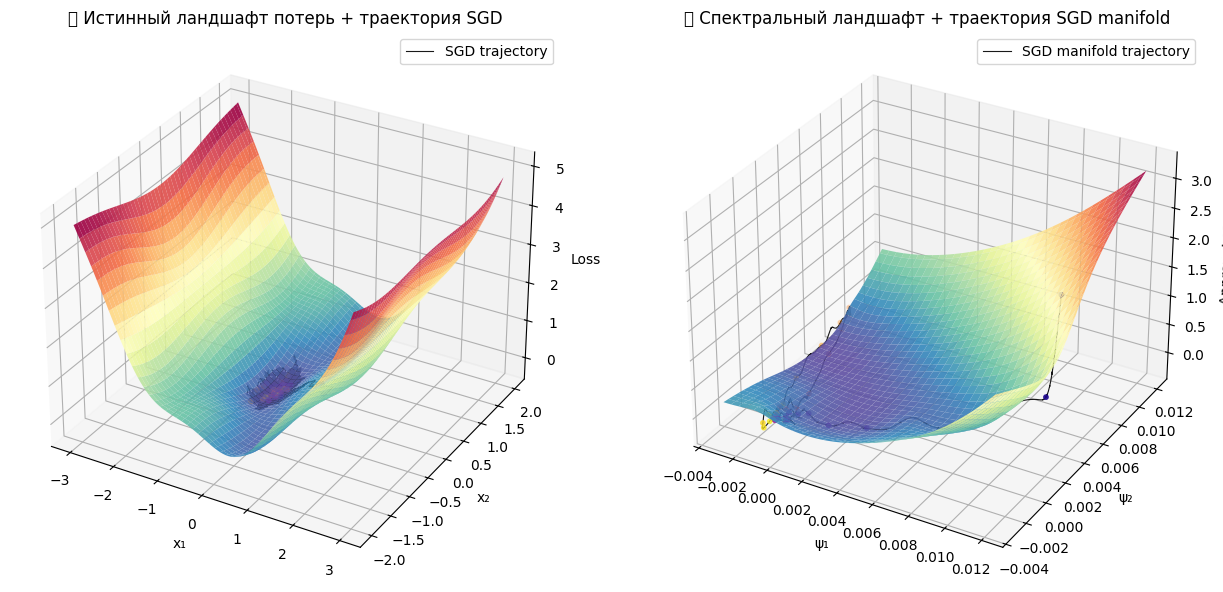

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import SpectralEmbedding
from scipy.interpolate import Rbf
from mpl_toolkits.mplot3d import Axes3D

# === 1️⃣ "Истинный" ландшафт потерь (x1, x2) ===
def true_loss(x1, x2):
    return 0.5*(x1**2 + 0.2*x2**2) + 0.3*np.sin(3*x1)*np.cos(2*x2)

# === 2️⃣ Полный 10D loss с шумовыми направлениями ===
def loss(theta):
    x1, x2 = theta[0], theta[1]
    rest = theta[2:]
    return true_loss(x1, x2) + 0.1*np.sum(rest**2)

def grad(theta):
    x1, x2 = theta[0], theta[1]
    rest = theta[2:]
    g = np.zeros_like(theta)
    g[0] = x1 + 0.9*np.cos(3*x1)*np.cos(2*x2)
    g[1] = 0.2*x2 - 0.6*np.sin(3*x1)*np.sin(2*x2)
    g[2:] = 0.2 * rest
    return g

# === 3️⃣ Симуляция стохастического GD в R^10 ===
def simulate_sgd(n_steps=4000, eta=0.03, noise_std=0.05):
    dim = 10
    traj = np.zeros((n_steps, dim))
    theta = np.random.randn(dim) * 2.0
    for t in range(n_steps):
        g = grad(theta)
        noise = np.random.randn(dim) * noise_std
        theta = theta - eta * g + noise
        traj[t] = theta
    return traj

np.random.seed(42)
traj = simulate_sgd()
loss_vals = np.array([loss(theta) for theta in traj])

# === 4️⃣ Спектральное подпространство (10D → 3D) ===
embedding = SpectralEmbedding(n_components=3, n_neighbors=25).fit_transform(traj)

# === 5️⃣ Аппроксимация "эффективного" лосса на manifold (RBF) ===
x, y, z = embedding[:,0], embedding[:,1], embedding[:,2]
rbf = Rbf(x, y, z, loss_vals, function='multiquadric', smooth=0.5)

grid_lin = np.linspace(x.min(), x.max(), 70)
Xg, Yg = np.meshgrid(grid_lin, grid_lin)
Zg_spec = np.zeros_like(Xg)
for i in range(Xg.shape[0]):
    for j in range(Xg.shape[1]):
        Zg_spec[i,j] = rbf(Xg[i,j], Yg[i,j], 0.0)

# === 6️⃣ Истинный loss landscape ===
x1s = np.linspace(-3, 3, 100)
x2s = np.linspace(-2, 2, 100)
X1, X2 = np.meshgrid(x1s, x2s)
Z_true = true_loss(X1, X2)

# === 7️⃣ Визуализация сравнения спусков ===
fig = plt.figure(figsize=(13,6))

# (a) Реальный ландшафт + траектория SGD по x₁, x₂
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X1, X2, Z_true, cmap='Spectral_r', alpha=0.9, linewidth=0)
ax1.plot(
    traj[:,0], traj[:,1],
    true_loss(traj[:,0], traj[:,1]),
    color='black', lw=0.8, alpha=0.9, label="SGD trajectory"
)
ax1.scatter(traj[::100,0], traj[::100,1],
            true_loss(traj[::100,0], traj[::100,1]),
            c=np.arange(0,len(traj[::100])), cmap='plasma', s=10)
ax1.set_title("🎯 Истинный ландшафт потерь + траектория SGD")
ax1.set_xlabel("x₁"); ax1.set_ylabel("x₂"); ax1.set_zlabel("Loss")
ax1.view_init(30, -60)
ax1.legend()

# (b) Спектральный ландшафт + траектория на manifold
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(Xg, Yg, Zg_spec, cmap='Spectral_r', alpha=0.9, linewidth=0)
traj_z = rbf(embedding[:,0], embedding[:,1], embedding[:,2])
ax2.plot(embedding[:,0], embedding[:,1], traj_z,
         color='black', lw=0.8, alpha=0.9, label="SGD manifold trajectory")
ax2.scatter(embedding[::100,0], embedding[::100,1],
            traj_z[::100], c=np.arange(0,len(traj[::100])), cmap='plasma', s=10)
ax2.set_title("🌈 Спектральный ландшафт + траектория SGD manifold")
ax2.set_xlabel("ψ₁"); ax2.set_ylabel("ψ₂"); ax2.set_zlabel("Approx. Loss")
ax2.view_init(30, -60)
ax2.legend()

plt.tight_layout()
plt.show()


/tmp/ipython-input-3398166521.py:103: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3398166521.py:103: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


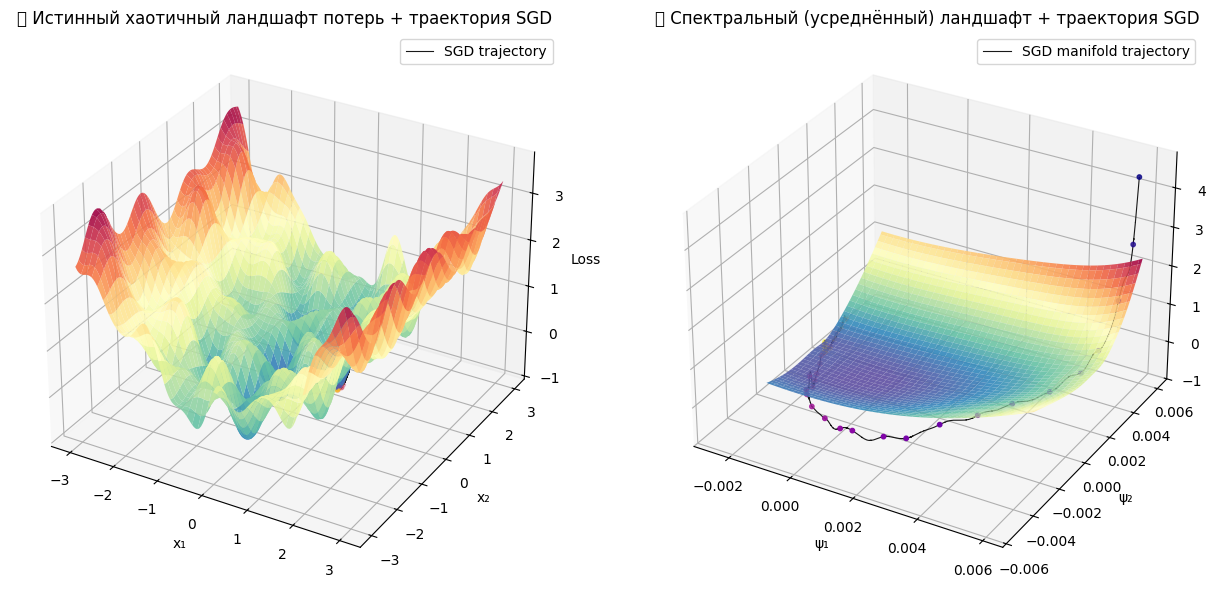

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import SpectralEmbedding
from scipy.interpolate import Rbf
from mpl_toolkits.mplot3d import Axes3D

# === 1️⃣ Сильно искривлённый многомодальный ландшафт (истинный) ===
def true_loss(x1, x2):
    """
    Хаотически искривлённый ландшафт:
    смесь нескольких частот синусоид, создающих сложные долины и барьеры.
    """
    base = 0.3 * (x1**2 + 0.2*x2**2)
    ripple1 = 0.5 * np.sin(3*x1) * np.cos(4*x2)
    ripple2 = 0.25 * np.sin(5*x1 + 1.5*x2)
    ripple3 = 0.2 * np.sin(7*x1) * np.sin(3.5*x2)
    ripple4 = 0.1 * np.cos(9*x1 - 4*x2)
    return base + ripple1 + ripple2 + ripple3 + ripple4

# === 2️⃣ Полный 10D loss с шумовыми направлениями ===
def loss(theta):
    x1, x2 = theta[0], theta[1]
    rest = theta[2:]
    return true_loss(x1, x2) + 0.1*np.sum(rest**2)

def grad(theta, eps=1e-4):
    """Численный градиент (чтобы корректно работать с хаотическими волнами)"""
    g = np.zeros_like(theta)
    for i in range(len(theta)):
        e = np.zeros_like(theta)
        e[i] = eps
        g[i] = (loss(theta + e) - loss(theta - e)) / (2*eps)
    return g

# === 3️⃣ Симуляция стохастического GD в R^10 ===
def simulate_sgd(n_steps=4000, eta=0.02, noise_std=0.05):
    dim = 10
    traj = np.zeros((n_steps, dim))
    theta = np.random.randn(dim) * 3.0
    for t in range(n_steps):
        g = grad(theta)
        noise = np.random.randn(dim) * noise_std
        theta = theta - eta * g + noise
        traj[t] = theta
    return traj

np.random.seed(42)
traj = simulate_sgd()
loss_vals = np.array([loss(theta) for theta in traj])

# === 4️⃣ Спектральное подпространство (10D → 3D) ===
embedding = SpectralEmbedding(n_components=3, n_neighbors=30).fit_transform(traj)

# === 5️⃣ Аппроксимация "эффективного" лосса на manifold (RBF) ===
x, y, z = embedding[:,0], embedding[:,1], embedding[:,2]
rbf = Rbf(x, y, z, loss_vals, function='multiquadric', smooth=0.7)

grid_lin = np.linspace(x.min(), x.max(), 80)
Xg, Yg = np.meshgrid(grid_lin, grid_lin)
Zg_spec = np.zeros_like(Xg)
for i in range(Xg.shape[0]):
    for j in range(Xg.shape[1]):
        Zg_spec[i,j] = rbf(Xg[i,j], Yg[i,j], 0.0)

# === 6️⃣ Истинный loss landscape ===
x1s = np.linspace(-3, 3, 150)
x2s = np.linspace(-3, 3, 150)
X1, X2 = np.meshgrid(x1s, x2s)
Z_true = true_loss(X1, X2)

# === 7️⃣ Визуализация: сравнение спусков ===
fig = plt.figure(figsize=(13,6))

# (a) Истинный ландшафт + траектория SGD
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X1, X2, Z_true, cmap='Spectral_r', alpha=0.9, linewidth=0)
ax1.plot(
    traj[:,0], traj[:,1],
    true_loss(traj[:,0], traj[:,1]),
    color='black', lw=0.8, alpha=0.9, label="SGD trajectory"
)
ax1.scatter(traj[::100,0], traj[::100,1],
            true_loss(traj[::100,0], traj[::100,1]),
            c=np.arange(0,len(traj[::100])), cmap='plasma', s=10)
ax1.set_title("🎯 Истинный хаотичный ландшафт потерь + траектория SGD")
ax1.set_xlabel("x₁"); ax1.set_ylabel("x₂"); ax1.set_zlabel("Loss")
ax1.view_init(30, -60)
ax1.legend()

# (b) Спектральный (эффективный) manifold + траектория
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(Xg, Yg, Zg_spec, cmap='Spectral_r', alpha=0.9, linewidth=0)
traj_z = rbf(embedding[:,0], embedding[:,1], embedding[:,2])
ax2.plot(embedding[:,0], embedding[:,1], traj_z,
         color='black', lw=0.8, alpha=0.9, label="SGD manifold trajectory")
ax2.scatter(embedding[::100,0], embedding[::100,1],
            traj_z[::100], c=np.arange(0,len(traj[::100])), cmap='plasma', s=10)
ax2.set_title("🌈 Спектральный (усреднённый) ландшафт + траектория SGD")
ax2.set_xlabel("ψ₁"); ax2.set_ylabel("ψ₂"); ax2.set_zlabel("Approx. Loss")
ax2.view_init(30, -60)
ax2.legend()

plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


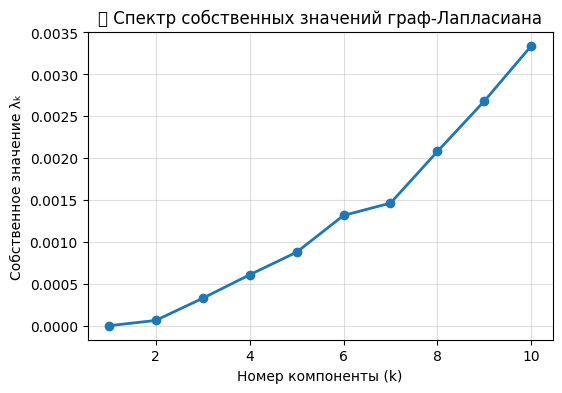

📈 Корреляция спектральных компонент с реальными координатами SGD:
ψ₁ ↔ x₁: 0.768
ψ₂ ↔ x₂: 0.403
ψ₃ ↔ x₃: -0.352


In [ ]:
# === 8️⃣ Анализ спектра Лапласиана и информативных направлений ===
from sklearn.metrics.pairwise import pairwise_distances
from scipy.sparse import csgraph
from scipy.sparse.linalg import eigsh

# 1️⃣ Строим граф ближайших соседей
n_neighbors = 30
dist = pairwise_distances(traj)
idx = np.argsort(dist, axis=1)[:, 1:n_neighbors+1]
rows = np.repeat(np.arange(len(traj)), n_neighbors)
cols = idx.flatten()
weights = np.exp(-dist[rows, cols]**2 / (2 * np.median(dist)**2))

# 2️⃣ Разреженная матрица смежности
from scipy.sparse import csr_matrix
W = csr_matrix((weights, (rows, cols)), shape=(len(traj), len(traj)))
W = 0.5 * (W + W.T)

# 3️⃣ Нормализованный Лапласиан
L = csgraph.laplacian(W, normed=True)

# 4️⃣ Собственные значения Лапласиана
vals, vecs = eigsh(L, k=10, which='SM')

# === 5️⃣ Визуализация спектра ===
plt.figure(figsize=(6,4))
plt.plot(np.arange(1, 11), vals, marker='o', lw=2)
plt.title("📊 Спектр собственных значений граф-Лапласиана")
plt.xlabel("Номер компоненты (k)")
plt.ylabel("Собственное значение λₖ")
plt.grid(alpha=0.4)
plt.show()

# === 6️⃣ Корреляция направлений с реальными координатами ===
import pandas as pd

embedding_full = vecs[:, 1:4]  # первые 3 нетривиальные компоненты
corr_x1 = np.corrcoef(embedding_full[:,0], traj[:,0])[0,1]
corr_x2 = np.corrcoef(embedding_full[:,1], traj[:,1])[0,1]
corr_x3 = np.corrcoef(embedding_full[:,2], traj[:,2])[0,1]

print("📈 Корреляция спектральных компонент с реальными координатами SGD:")
print(f"ψ₁ ↔ x₁: {corr_x1:.3f}")
print(f"ψ₂ ↔ x₂: {corr_x2:.3f}")
print(f"ψ₃ ↔ x₃: {corr_x3:.3f}")
